# EDA: Exploratory Data Analysis of GDP across 514 Districts in Indonesia

**Focus:** Exploratory Data Analysis (EDA) of district-level GDP in Indonesia for **2015** and **2025**.



**Data:**
- GDP: [`quarcs-lab/indonesia514`](https://github.com/quarcs-lab/indonesia514/blob/main/gdp/gdp.csv)
- Map (actual polygons): `maps/mapIndonesia514_new.geojson`
- Map (Thiessen polygons for W matrix): `maps/mapIndonesia514_new_tp.geojson`


**Authors:** Mendez, C., Abdulah, R., & Arvianto, B. (2026). *Indonesia514*. QuaRCS Lab.

---

## 0 | Install & Import Libraries

In [ ]:
# Install required packages (run once in Colab)
!pip install pysal libpysal esda splot geopandas mapclassify -q

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# PySAL / ESDA
import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from splot.esda import (
    moran_scatterplot,
    plot_moran,
    lisa_cluster,
    plot_local_autocorrelation
)
import splot

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully.')
print(f'  geopandas : {gpd.__version__}')
print(f'  libpysal  : {libpysal.__version__}')
print(f'  esda      : {splot.__version__}')

Libraries loaded successfully.
  geopandas : 1.1.3
  libpysal  : 4.14.1
  esda      : 1.1.7


## 1 | Load Data

In [ ]:
# ---------------------------------------------------------------------------
# 1.1  Define source URLs
# ---------------------------------------------------------------------------
REPO_URL = "https://raw.githubusercontent.com/quarcs-lab/indonesia514/main"

url_gdp    = f"{REPO_URL}/gdp/gdp.csv"
url_map    = f"{REPO_URL}/maps/mapIndonesia514_new.geojson"      # actual polygons (visualisation)
url_map_tp = f"{REPO_URL}/maps/mapIndonesia514_new_tp.geojson"   # Thiessen polygons (W matrix)

# ---------------------------------------------------------------------------
# 1.2  Load GDP data
# ---------------------------------------------------------------------------
print('Loading GDP data ...')
df_gdp = pd.read_csv(url_gdp)
df_gdp['districtID'] = df_gdp['districtID'].astype(str).str.zfill(4)

print(f'  Shape: {df_gdp.shape}')
print(f'  Columns: {list(df_gdp.columns)}')
df_gdp.head(3)

Loading GDP data ...
  Shape: (514, 28)
  Columns: ['fid', 'districtID', 'districtID_old', 'nameID', 'district_en', 'provinceID', 'province_bahasa', 'province_en', 'islandID', 'island_bahasa', 'island_en', 'district_bahasa', 'gdp_2010', 'gdp_2011', 'gdp_2012', 'gdp_2013', 'gdp_2014', 'gdp_2015', 'gdp_2016', 'gdp_2017', 'gdp_2018', 'gdp_2019', 'gdp_2020', 'gdp_2021', 'gdp_2022', 'gdp_2023', 'gdp_2024', 'gdp_2025']


,fid,districtID,districtID_old,nameID,district_en,provinceID,province_bahasa,province_en,islandID,island_bahasa,...,gdp_2016,gdp_2017,gdp_2018,gdp_2019,gdp_2020,gdp_2021,gdp_2022,gdp_2023,gdp_2024,gdp_2025
0,1,1101,1101,simeulue,Simeulue,11,Aceh,Aceh,1,Sumatera,...,1405.84,1467.98,1530.15,1600.52,1602.41,1657.03,1726.61,1806.62,1886.61,1958.50
1,2,1102,1102,acehsingkil,Aceh Singkil,11,Aceh,Aceh,1,Sumatera,...,1540.65,1600.98,1664.74,1731.17,1713.66,1780.42,1844.65,1909.66,1975.75,2043.19
2,3,1103,1103,acehselatan,South Aceh,11,Aceh,Aceh,1,Sumatera,...,3740.29,3887.22,4063.41,4243.40,4241.41,4345.78,4480.84,4639.20,4788.29,4931.74


In [ ]:
# ---------------------------------------------------------------------------
# 1.3  Load GeoJSON files
# ---------------------------------------------------------------------------
print('Loading actual district polygons (for maps) ...')
gdf_map = gpd.read_file(url_map)
gdf_map['districtID'] = gdf_map['districtID'].astype(str).str.zfill(4)
print(f'  Shape: {gdf_map.shape}  |  CRS: {gdf_map.crs}')

print('Loading Thiessen polygons (for W matrix) ...')
gdf_tp = gpd.read_file(url_map_tp)
gdf_tp['districtID'] = gdf_tp['districtID'].astype(str).str.zfill(4)
print(f'  Shape: {gdf_tp.shape}  |  CRS: {gdf_tp.crs}')

Loading actual district polygons (for maps) ...
  Shape: (514, 9)  |  CRS: EPSG:4326
Loading Thiessen polygons (for W matrix) ...
  Shape: (514, 10)  |  CRS: EPSG:4326


## 2 | Merge GDP with GeoData

In [ ]:
# Keep only the columns we need from the GDP data
gdp_cols = ['districtID', 'district_en', 'province_en', 'island_en',
            'gdp_2015', 'gdp_2025']
df_sub = df_gdp[gdp_cols].copy()

# Compute log GDP (better for spatial analysis; removes skewness)
df_sub['ln_gdp_2015'] = np.log(df_sub['gdp_2015'])
df_sub['ln_gdp_2025'] = np.log(df_sub['gdp_2025'])

# Compute GDP growth 2010-2025 (annualised, %)
df_sub['gdp_growth'] = ((df_sub['gdp_2025'] / df_sub['gdp_2015']) ** (1/9) - 1) * 100

# ---- Merge with actual map (for visualisation) ----
gdf = gdf_map.merge(df_sub, on='districtID', how='left')
print(f'Merged map GDF shape: {gdf.shape}')
print(f'Missing GDP values: {gdf["gdp_2015"].isna().sum()}')

# ---- Merge with Thiessen polygons (for W matrix) ----
gdf_tp_merged = gdf_tp.merge(df_sub, on='districtID', how='left')
# Ensure same row ordering for W matrix consistency
gdf_tp_merged = gdf_tp_merged.sort_values('districtID').reset_index(drop=True)
gdf = gdf.merge(
    gdf_tp_merged[['districtID']].reset_index().rename(columns={'index': 'tp_idx'}),
    on='districtID', how='left'
)

df_sub.describe()

Merged map GDF shape: (514, 17)
Missing GDP values: 0


,gdp_2015,gdp_2025,ln_gdp_2015,ln_gdp_2025,gdp_growth
count,514.00,514.00,514.00,514.00,514.00
mean,17604.03,26847.39,8.87,9.29,4.77
std,37897.65,58869.60,1.28,1.28,2.53
min,113.07,185.08,4.73,5.22,-1.98
25%,2913.84,4324.81,7.98,8.37,4.10
50%,6844.58,10866.08,8.83,9.29,4.64
75%,15849.45,24079.29,9.67,10.09,5.16
max,355092.53,560760.04,12.78,13.24,43.67


## 3 | Exploratory Data Analysis (Non-Spatial)

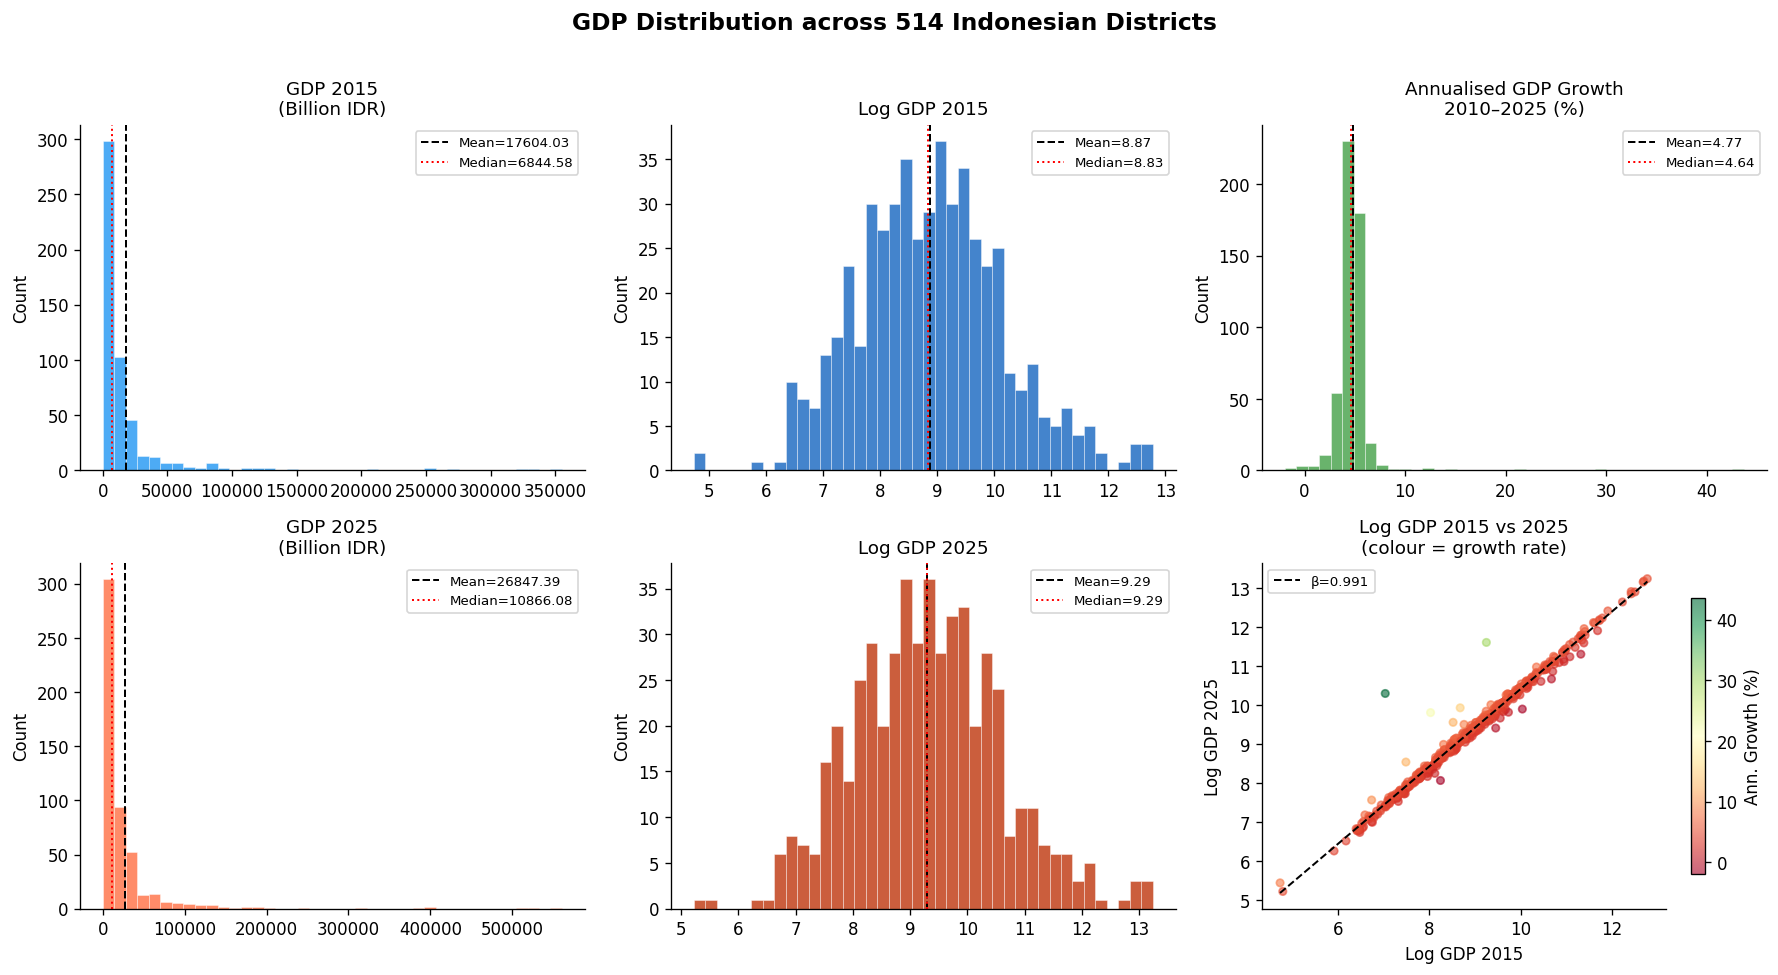

Figure saved: fig1_gdp_distributions.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('GDP Distribution across 514 Indonesian Districts', fontsize=14, fontweight='bold', y=1.01)

years_vars = [
    ('gdp_2015',    'GDP 2015\n(Billion IDR)',         axes[0, 0]),
    ('ln_gdp_2015', 'Log GDP 2015',                    axes[0, 1]),
    ('gdp_2025',    'GDP 2025\n(Billion IDR)',         axes[1, 0]),
    ('ln_gdp_2025', 'Log GDP 2025',                    axes[1, 1]),
    ('gdp_growth',  'Annualised GDP Growth\n2010–2025 (%)', axes[0, 2]),
]

colors = ['#2196F3', '#1565C0', '#FF7043', '#BF360C', '#43A047']

for (col, label, ax), color in zip(years_vars, colors):
    data = df_sub[col].dropna()
    # Filter out infinite values from the data
    data = data[np.isfinite(data)]
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.2f}')
    ax.axvline(data.median(), color='red', linestyle=':', linewidth=1.2, label=f'Median={data.median():.2f}')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

# Scatter: GDP 2010 vs 2025
ax = axes[1, 2]
# Filter out rows where either ln_gdp_2010 or ln_gdp_2025 is NaN or inf for polyfit and scatter
data_for_scatter = df_sub[['ln_gdp_2015', 'ln_gdp_2025', 'gdp_growth']].dropna()
data_for_scatter = data_for_scatter[np.isfinite(data_for_scatter['ln_gdp_2015'])]
data_for_scatter = data_for_scatter[np.isfinite(data_for_scatter['ln_gdp_2025'])]

sc = ax.scatter(data_for_scatter['ln_gdp_2015'], data_for_scatter['ln_gdp_2025'],
                c=data_for_scatter['gdp_growth'], cmap='RdYlGn', alpha=0.6, s=20)
m, b = np.polyfit(data_for_scatter['ln_gdp_2015'], data_for_scatter['ln_gdp_2025'], 1)
x_line = np.linspace(data_for_scatter['ln_gdp_2015'].min(), data_for_scatter['ln_gdp_2015'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.2, label=f'β={m:.3f}')
ax.set_xlabel('Log GDP 2015', fontsize=10)
ax.set_ylabel('Log GDP 2025', fontsize=10)
ax.set_title('Log GDP 2015 vs 2025\n(colour = growth rate)', fontsize=11)
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.colorbar(sc, ax=ax, shrink=0.8, label='Ann. Growth (%)')

plt.tight_layout()
plt.savefig('fig1_gdp_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig1_gdp_distributions.png')

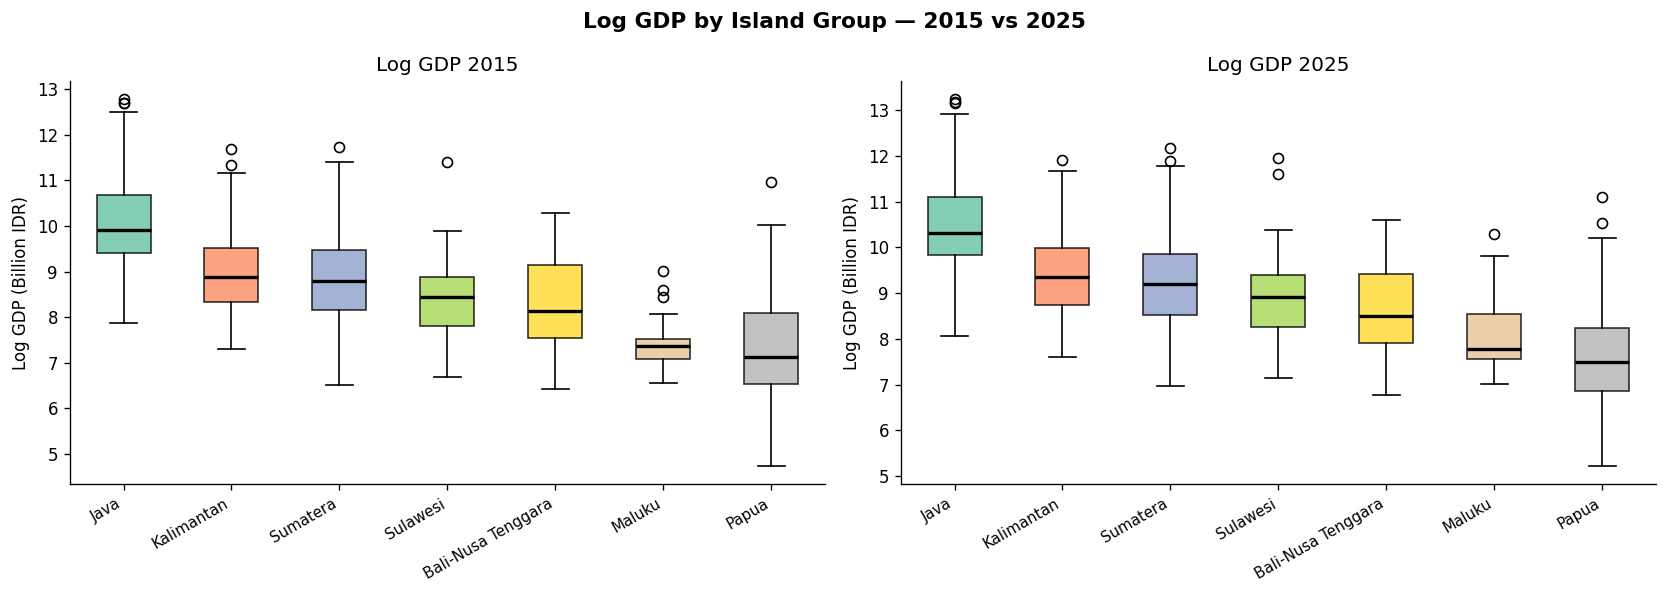

In [ ]:
# GDP by island group — box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Log GDP by Island Group — 2015 vs 2025', fontsize=13, fontweight='bold')

island_order = (df_sub.groupby('island_en')['gdp_2025']
                .median().sort_values(ascending=False).index.tolist())

for ax, (col, year) in zip(axes, [('ln_gdp_2015', '2015'), ('ln_gdp_2025', '2025')]):
    data_by_island = [df_sub.loc[df_sub['island_en'] == isl, col].dropna().values
                      for isl in island_order]
    bp = ax.boxplot(data_by_island, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    colors_box = plt.cm.Set2(np.linspace(0, 1, len(island_order)))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(island_order, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Log GDP (Billion IDR)')
    ax.set_title(f'Log GDP {year}')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_gdp_by_island.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 | Choropleth Maps — GDP 2015 and 2025

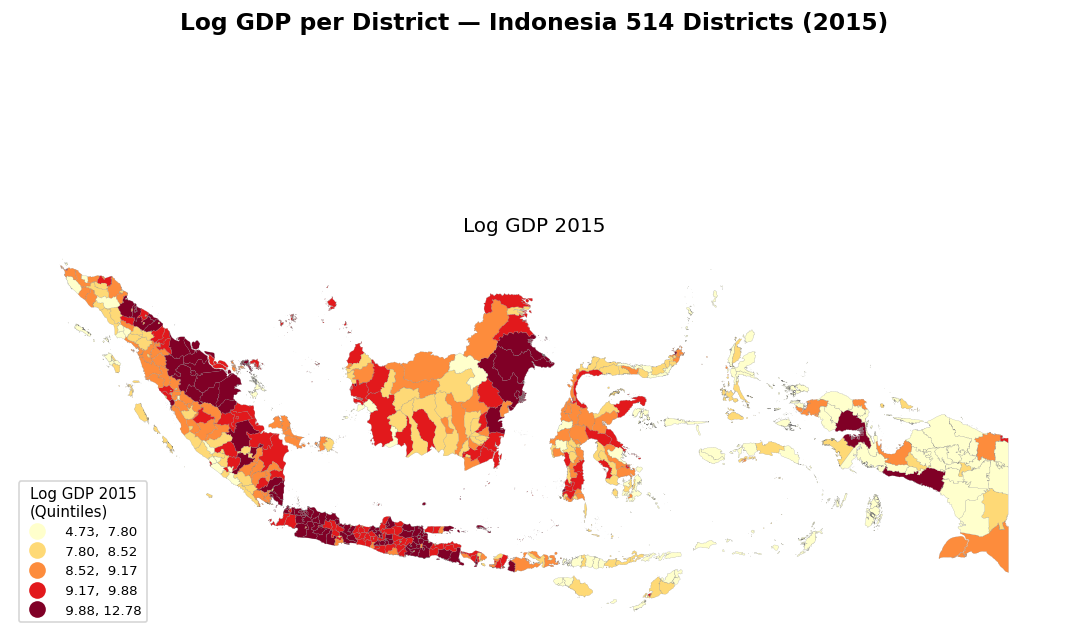

Figure saved: fig3_choropleth_gdp_2015.png


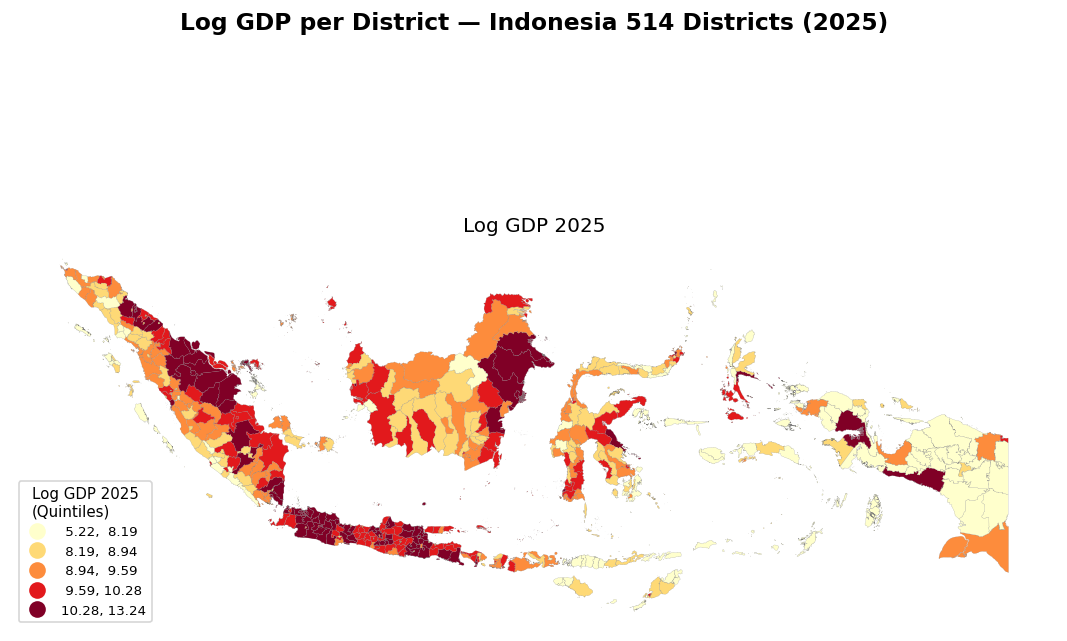

Figure saved: fig3_choropleth_gdp_2025.png


In [74]:
import mapclassify

# --- Choropleth Map for Log GDP 2015 ---
fig_2015, ax_2015 = plt.subplots(1, 1, figsize=(9, 7))
fig_2015.suptitle('Log GDP per District — Indonesia 514 Districts (2015)', fontsize=14, fontweight='bold')

gdf.plot(
    column='ln_gdp_2015',
    ax=ax_2015,
    scheme='quantiles',
    k=5,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={
        'title': 'Log GDP 2015\n(Quintiles)',
        'loc': 'lower left',
        'fontsize': 8,
        'title_fontsize': 9
    },
    edgecolor='grey',
    linewidth=0.1,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax_2015.set_title('Log GDP 2015', fontsize=12)
ax_2015.set_axis_off()

plt.tight_layout()
plt.savefig('fig3_choropleth_gdp_2015.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig3_choropleth_gdp_2015.png')

# --- Choropleth Map for Log GDP 2025 ---
fig_2025, ax_2025 = plt.subplots(1, 1, figsize=(9, 7))
fig_2025.suptitle('Log GDP per District — Indonesia 514 Districts (2025)', fontsize=14, fontweight='bold')

gdf.plot(
    column='ln_gdp_2025',
    ax=ax_2025,
    scheme='quantiles',
    k=5,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={
        'title': 'Log GDP 2025\n(Quintiles)',
        'loc': 'lower left',
        'fontsize': 8,
        'title_fontsize': 9
    },
    edgecolor='grey',
    linewidth=0.1,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax_2025.set_title('Log GDP 2025', fontsize=12)
ax_2025.set_axis_off()

plt.tight_layout()
plt.savefig('fig3_choropleth_gdp_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig3_choropleth_gdp_2025.png')

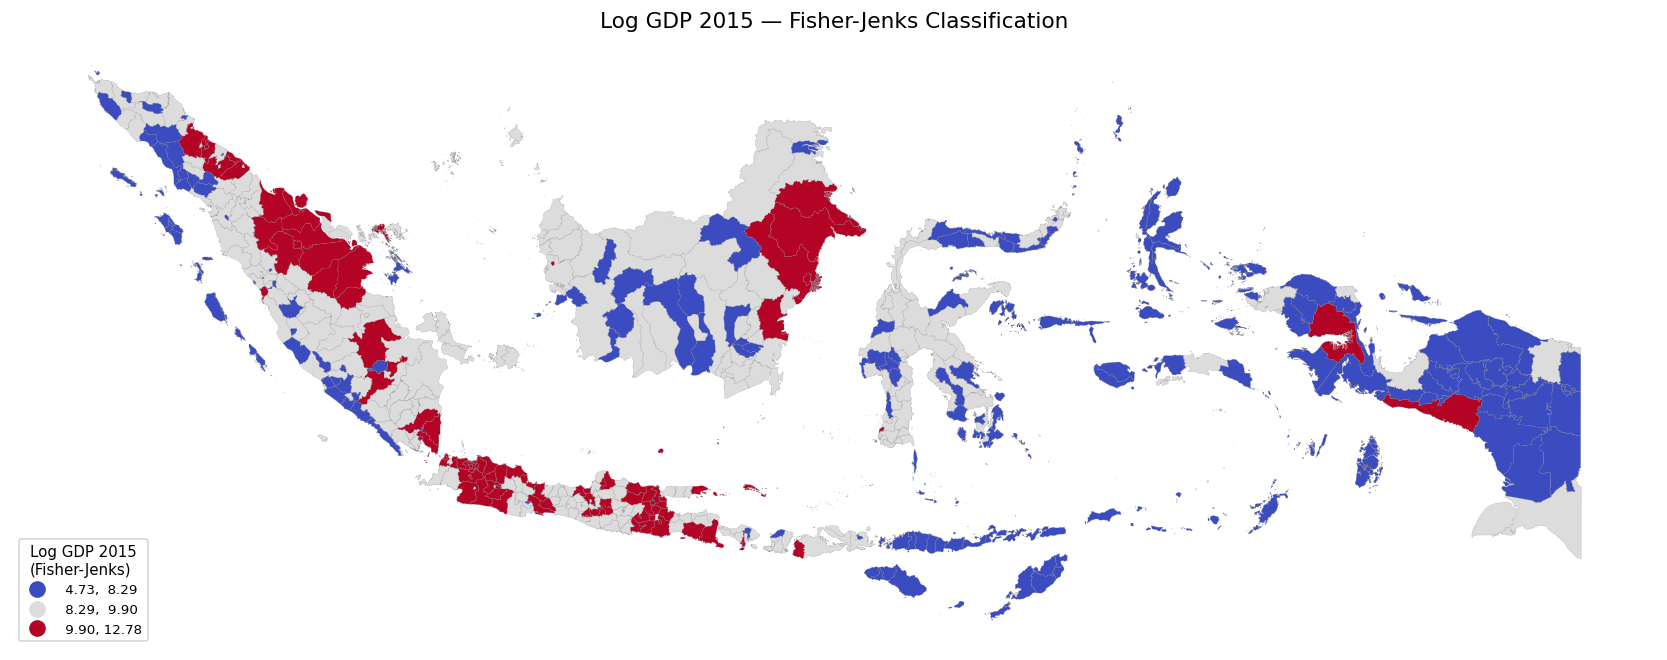

Figure saved: gdp_2015_fisherjenks_map.png


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

gdf.plot(
    column='ln_gdp_2015',
    ax=ax,
    scheme='FisherJenks',
    k=3, # User-specified number of classes
    cmap='coolwarm',
    legend=True,
    legend_kwds={
        'title': 'Log GDP 2015\n(Fisher-Jenks)',
        'loc': 'lower left',
        'fontsize': 8,
        'title_fontsize': 9
    },
    edgecolor='grey',
    linewidth=0.1,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax.set_title('Log GDP 2015 — Fisher-Jenks Classification', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('gdp_2015_fisherjenks_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gdp_2015_fisherjenks_map.png')

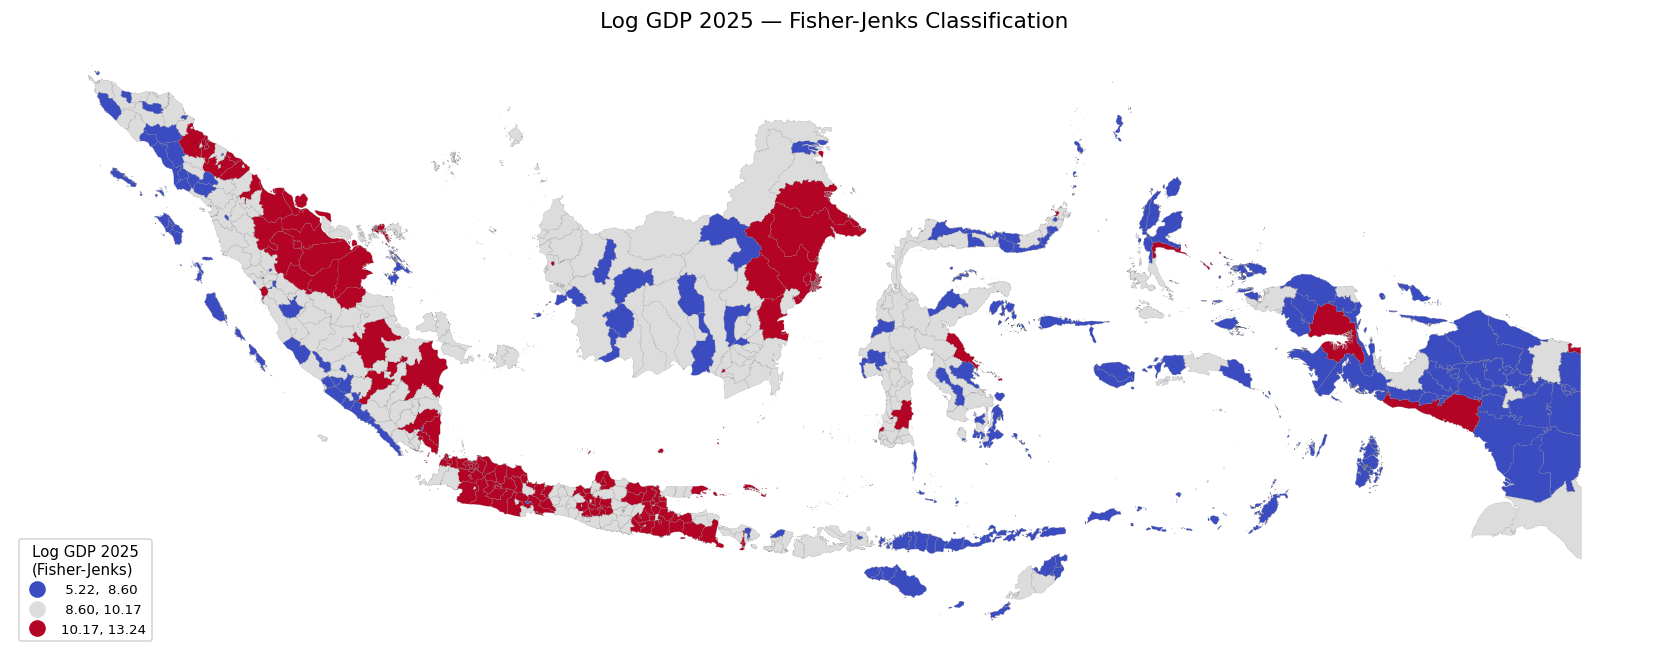

Figure saved: gdp_2025_fisherjenks_map.png


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

gdf.plot(
    column='ln_gdp_2025',
    ax=ax,
    scheme='FisherJenks',
    k=3, # User-specified number of classes
    cmap='coolwarm',
    legend=True,
    legend_kwds={
        'title': 'Log GDP 2025\n(Fisher-Jenks)',
        'loc': 'lower left',
        'fontsize': 8,
        'title_fontsize': 9
    },
    edgecolor='grey',
    linewidth=0.1,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax.set_title('Log GDP 2025 — Fisher-Jenks Classification', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('gdp_2025_fisherjenks_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gdp_2025_fisherjenks_map.png')

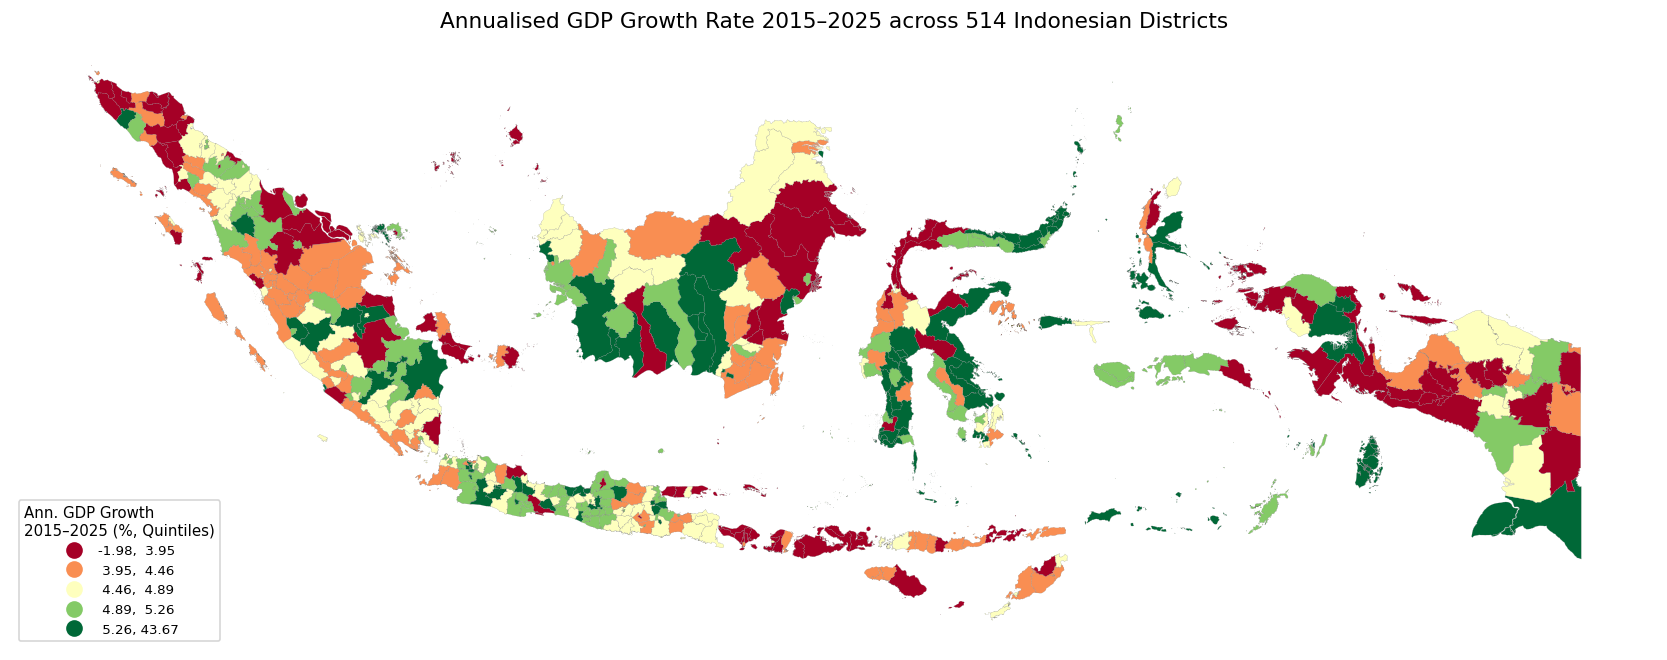

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

gdf.plot(
    column='gdp_growth',
    ax=ax,
    scheme='quantiles',
    k=5,
    cmap='RdYlGn',
    legend=True,
    legend_kwds={
        'title': 'Ann. GDP Growth\n2015–2025 (%, Quintiles)',
        'loc': 'lower left',
        'fontsize': 8,
        'title_fontsize': 9
    },
    edgecolor='grey',
    linewidth=0.1,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax.set_title('Annualised GDP Growth Rate 2015–2025 across 514 Indonesian Districts', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('fig4_choropleth_growth.png', dpi=150, bbox_inches='tight')
plt.show()

###Dynamic Map of GDP

#### GDP 2015

In [ ]:
gdf.explore(
    column='ln_gdp_2015', # Primary indicator for coloring
    tooltip=['district_en_y', 'province_en', 'ln_gdp_2015', 'gdp_growth'],
    scheme='quantiles', # 'quintile classification' requested by user
    k=6,
    cmap='coolwarm',
    legend=True,
    tiles='CartoDB positron',
    style_kwds=dict(color="gray", weight=0.4),
    legend_kwds=dict(colorbar=False)
)

Output hidden; open in https://colab.research.google.com to view.

####GDP 2025

In [75]:
gdf.explore(
    column='ln_gdp_2025', # Primary indicator for coloring
    tooltip=['district_en_y', 'province_en', 'ln_gdp_2025', 'gdp_growth'],
    scheme='quantiles', # 'quintile classification' requested by user
    k=6,
    cmap='coolwarm',
    legend=True,
    tiles='CartoDB positron',
    style_kwds=dict(color="gray", weight=0.4),
    legend_kwds=dict(colorbar=False)
)

Output hidden; open in https://colab.research.google.com to view.

## 5 | Conclusions

This notebook conducted an Exploratory Data Analysis (EDA) of GDP across **514 Indonesian districts** for the years **2015** and **2025**.

**Key findings:**

1.  **GDP distribution:** The raw GDP values are highly skewed, indicating a few districts with very high GDP. Log transformation effectively normalized these distributions, making them more suitable for analysis.
2.  **GDP growth:** There is significant variation in annualised GDP growth rates across districts, with some experiencing negative growth and others very high growth. The scatter plot of Log GDP 2015 vs. 2025 suggests a strong positive correlation, indicating that districts with higher GDP in 2015 generally also have higher GDP in 2025.
3.  **Island-level disparities:** Significant differences in Log GDP exist across island groups, with certain islands exhibiting generally higher GDP levels than others in both 2015 and 2025.

**Next steps:**
- Spatial panel econometrics (SAR, SEM, SDM) on the full 2015–2025 panel
- Convergence club analysis using `ConvergenceClubs` (Phillips & Sul, 2007)
- Integration with GFCF and Government Spending data

---
*Repository: [quarcs-lab/indonesia514](https://github.com/quarcs-lab/indonesia514)*